# ***Final Assignment: X-Ray images classification***
---
*   Meri Ferretti (10666970)
*   Diana Nigrisoli (10824967)
*   Laura Pozzi (10868694)

In this script our ***first and most basic approach*** is illustrated.


Firstly we created the dataset simply splitting the resized images into training, validation and test set (paying attention to put all the images related to a patient into the same subset). Then we moved to the training part where we tried 2 tecniques: 

1.   Transfer learning + Fine tuning using EfficientNetB3 and a customized Fully Connected network
2.   Features extraction using EfficientNetB3 + Classification through a Machine Learning model


---


### Mounting | Importing | Seed

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project

/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project


In [ ]:
import os
import sys
import cv2
import math
import json
import random
import shutil
import tarfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
tfk = tf.keras
tfkl = tf.keras.layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense,Flatten,Input,Lambda,GlobalAveragePooling2D,Dropout,Conv2D,BatchNormalization,MaxPooling2D,Input,Activation
from tensorflow.keras.models import load_model,Model,Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array,array_to_img
from tensorflow.keras.optimizers import Adam,RMSprop,SGD
from tensorflow.keras.applications.densenet import DenseNet169, preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter, defaultdict
import matplotlib.patches as patches
from glob import glob
from PIL import Image
plt.rc('font', size=16) 

In [ ]:
### Random seed for reproducibility
seed = 42   

random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.compat.v1.set_random_seed(seed)

### Creating the dataset for Option 1

N.B. ***We DO NOT recommend to run this section cause It could last a huge amount of time***

In [ ]:
### Loading resized images 
normal_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized/Normal'
tube_dir = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized/Tuberculosis'
pneumo_dir = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized/Pneumonia'

In [ ]:
print('Normal:', len(os.listdir(normal_dir)))
print('Pneumonia:', len(os.listdir(pneumo_dir)))
print('Tuberculosis:', len(os.listdir(tube_dir)))

Normal: 9354
Pneumonia: 4250
Tuberculosis 1866


In [ ]:
### Functions definition 

def division_per_class(x,y,class_name,n_sample = None):
  return x[y==MAPPING[class_name]] 

def division_per_n_pict(x,y,n_pict):
  return x[y==n_pict] 

def select_image_per_patient(list_image_class, list_patient_set):
  list_img_set = []
  for img in list_image_class:
    for pat in list_patient_set:
      if (img[:6] == pat):
        list_img_set.append(img)
  return list_img_set

def split_per_class(data, train_ratio, val_ratio, test_ratio):
  # 1. extract patients 
  patients_list = []
  for sample in data:
    patients_list.append(sample[:6])
    
  (list_pat_unique, counts_pat) = np.unique(patients_list, return_counts=True)

  # 2. considering separately patients with 1 picture and 2 pictures
  pat_1pict = division_per_n_pict(list_pat_unique,counts_pat,1)
  pat_2pict = division_per_n_pict(list_pat_unique,counts_pat,2)

  # 3. splitting the 2 patients lists into training, validation and test
  train_1p, remaining_1p = train_test_split(pat_1pict, test_size=1 - train_ratio, shuffle = True, random_state = 100)
  val_1p, test_1p = train_test_split(remaining_1p, test_size=test_ratio/(test_ratio + val_ratio), shuffle = True,random_state = 100) 

  train_2p, remaining_2p = train_test_split(pat_2pict, test_size=1 - train_ratio , shuffle = True,random_state = 100)
  val_2p, test_2p = train_test_split(remaining_2p, test_size=test_ratio/(test_ratio + val_ratio), shuffle = True,random_state = 100)

  # 4. Merging patients lists belonging to the same subset (training, validation or test)
  list_pat_train = np.concatenate([train_1p, train_2p])
  list_pat_val = np.concatenate([val_1p, val_2p])
  list_pat_test = np.concatenate([test_1p, test_2p])

  # 5. Creating subsets containing the complete image names 
  train_set = select_image_per_patient(data,list_pat_train)
  val_set = select_image_per_patient(data,list_pat_val)
  test_set = select_image_per_patient(data,list_pat_test)

  return train_set, val_set, test_set

In [ ]:
### Creating array of labels and array of file names
labels = pd.read_csv('/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/labels_train.csv')
labels_df = pd.DataFrame(labels)

y = labels_df["label"]
x = labels_df["file"]

y_array = y.to_numpy()
x_array = x.to_numpy()

In [ ]:
### Dividing images names according to their label
MAPPING = {
    "Normal": "N",
    "Pneumonia": "P",
    "Tuberculosis": "T",
}

normal = division_per_class(x_array,y_array,"Normal")
pneumo = division_per_class(x_array,y_array,"Pneumonia")
tube = division_per_class(x_array,y_array,"Tuberculosis")

In [ ]:
### Creating the 3 subsets (training, validation and test) containing file names 
normal_train, normal_val, normal_test = split_per_class(normal, 0.7, 0.2, 0.1)
pneumo_train, pneumo_val, pneumo_test = split_per_class(pneumo, 0.7, 0.2, 0.1)
tube_train, tube_val, tube_test = split_per_class(tube, 0.7, 0.2, 0.1)

In [ ]:
### Iterate on all file names to copy them from the source to the destination folders 
source = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized'
train_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Dataset_Option1/Train'
val_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Dataset_Option1/Validation'
test_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Dataset_Option1/Test'

In [ ]:
for f in normal_train:
  shutil.copy(source + '/' + 'Normal'+ '/' + f, train_dir + '/' + 'Normal'+ '/' + f )
for f in normal_val:
  shutil.copy(source + '/' + 'Normal'+ '/' + f, val_dir + '/' + 'Normal'+ '/' +  f )
for f in normal_test:
  shutil.copy(source + '/' + 'Normal'+ '/' + f, test_dir + '/' + 'Normal'+ '/' + f )

for f in pneumo_train:
  shutil.copy(source + '/' + 'Pneumonia'+ '/' + f, train_dir + '/' + 'Pneumonia'+ '/' + f )
for f in pneumo_val:
  shutil.copy(source + '/' + 'Pneumonia'+ '/' + f, val_dir + '/' + 'Pneumonia'+ '/' +  f )
for f in pneumo_test:
  shutil.copy(source + '/' + 'Pneumonia'+ '/' + f, test_dir + '/' + 'Pneumonia'+ '/' + f )

for f in tube_train:
  shutil.copy(source + '/' + 'Tuberculosis'+ '/' + f, train_dir + '/' + 'Tuberculosis'+ '/' + f )
for f in tube_val:
  shutil.copy(source + '/' + 'Tuberculosis'+ '/' + f, val_dir + '/' + 'Tuberculosis'+ '/' +  f )
for f in tube_test:
  shutil.copy(source + '/' + 'Tuberculosis'+ '/' + f, test_dir + '/' + 'Tuberculosis'+ '/' + f )

### Training 1
Transfer Learning + Fine Tuning using EfficientNetB3

#### 1 - Data generators

In [ ]:
train_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Dataset_Option1/Train'
val_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Dataset_Option1/Validation'
test_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Dataset_Option1/Test'

In [ ]:
### Defining ROIs coordinates
img_size = 256 # image height = image width
roi_size = 10 # ROI height = ROI width

# roi 1 (top-left)
w1_start = 4
h1_start = 32
# roi 2 (top-right)
w2_start = img_size - 4 - roi_size
h2_start = 4
# roi 3 (center-right)
w3_start = img_size - 4 - roi_size
h3_start = 120
# roi 4 (bottom-right)
w4_start = img_size - 4 - roi_size
h4_start = img_size - 32 - roi_size
# roi 5 (bottom-left)
w5_start = 4
h5_start = img_size - 4 - roi_size
# roi 6 (center-left)
w6_start = 4
h6_start = 120

In [ ]:
### Preprocessing function

def check_noise(img):
  
  noisy = False
  
  roi1 = img[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
  std1 = roi1.std()
  
  roi2 = img[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
  std2 = roi2.std()
 
  roi3 = img[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size]
  std3 = roi3.std()
  
  roi4 = img[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
  std4 = roi4.std()

  roi5 = img[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size]
  std5 = roi5.std()

  roi6 = img[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size]
  std6 = roi6.std()

  if (std1>20 and std2>20 and std3>20 and std4>20 and std5>20 and std6>20):
    noisy = True
    
  return noisy


def filter_function(img):
  
  noisy = check_noise(img)
  if noisy :
    return cv2.medianBlur(img, 5)
  else: 
    return img

In [ ]:
img_height = 256
img_width = 256
batch_size = 64

# No filtering
'''train_datagen = ImageDataGenerator() 
validation_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()'''

# With filtering
train_datagen = ImageDataGenerator(preprocessing_function = filter_function) 
validation_datagen = ImageDataGenerator(preprocessing_function= filter_function)
test_datagen = ImageDataGenerator(preprocessing_function= filter_function)

### Online importing
train_dataset = train_datagen.flow_from_directory(
    directory = train_dir,
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = True) 

validation_dataset = validation_datagen.flow_from_directory(
    directory = val_dir, 
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = False) 

test_dataset = test_datagen.flow_from_directory(
    directory = test_dir, 
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = False) 

Found 10825 images belonging to 3 classes.
Found 3093 images belonging to 3 classes.
Found 1552 images belonging to 3 classes.


#### 2 - Model definition

In [ ]:
### Functions used to define and build the model

# Preprocessing to be applied to the input images
from tensorflow.keras.applications.efficientnet import preprocess_input

def build_feat_extractor (img_height: int, img_width: int) -> tf.keras.Model:
    net = tfk.applications.EfficientNetB3(
          include_top = False,
          weights = "imagenet", 
          input_shape = (img_height, img_width, 3)
          ) 
    net.trainable = False 
    return net 

def build_model(feat_extractor,img_height,img_width,num_classes) -> tf.keras.Model:
    # Feature extractor
    inputs = tfk.Input(shape=(img_height,img_width,3))

    x = preprocess_input(inputs)
    x = feat_extractor(x, training = False)

    # Classifier
    dropout_rate = 0.4
    x = tfkl.Dropout(dropout_rate, seed=seed)(x)
    x = tfkl.GlobalAveragePooling2D()(x)
    x = tfkl.Dropout(dropout_rate, seed=seed)(x)
    x = tfkl.Dense(
        256, 
        activation='relu',
        kernel_initializer = tfk.initializers.HeUniform(seed)
    )(x)
    x = tfkl.Dropout(dropout_rate, seed=seed)(x)
    outputs = tfkl.Dense(
              num_classes, 
              activation='softmax',
              kernel_initializer = tfk.initializers.GlorotUniform(seed),
              kernel_regularizer = tfk.regularizers.L2(0.01),
    )(x)

    # Connecting input and output through the Model class
    model = tfk.Model(inputs=inputs, outputs=outputs, name='model')

    return model

def model_compile (model, learn_rate) ->None:
    optimizer=tfk.optimizers.Adam(learning_rate = learn_rate)
    model.compile(
          loss=tfk.losses.CategoricalCrossentropy(), 
          optimizer= optimizer,
          metrics='accuracy'
    )

In [ ]:
### Functions used in the evaluation phase  

def plot_history(history):
    hist = history
    plt.figure(figsize=(15, 5))
    plt.plot(hist["accuracy"], label="Training", alpha=0.8, color="#ff7f0e")
    plt.plot(hist["val_accuracy"], label="Validation", alpha=0.8, color="#4D61E2")
    plt.ylim(0, 1)
    plt.title("Accuracy")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    plt.figure(figsize=(15, 5))
    plt.plot(hist["loss"], label="Training", alpha=0.8, color="#ff7f0e")
    plt.plot(hist["val_loss"], label="Validation", alpha=0.8, color="#4D61E2")
    plt.title("Loss")
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    plt.show()

def evaluate(model: tf.keras.Model,dataset) -> None:
    predictions = model.predict(dataset)

    y_test = dataset.classes
    pred_number = np.argmax(predictions, axis=-1)
    compute_metrics(y_test, pred_number)

def compute_metrics(y_test, pred_number):
  
    # Computing confusion matrix
    cm = confusion_matrix(y_test, pred_number)

    # Computing classification metrics
    accuracy = accuracy_score(y_test, pred_number)
    precision = precision_score(y_test, pred_number, average='macro')
    recall = recall_score(y_test, pred_number, average='macro')
    f1 = f1_score(y_test, pred_number, average='weighted')

    # Printing classification metrics
    print('Accuracy:',accuracy.round(4))
    print('Precision:',precision.round(4))
    print('Recall:',recall.round(4))
    print('F1:',f1.round(4))

    # Plotting confusion matrix
    plt.figure(figsize=(10,8))
    sns.heatmap(cm.T, xticklabels=list(train_dataset.class_indices), yticklabels=list(train_dataset.class_indices), annot=True)
    plt.xlabel('True labels')
    plt.ylabel('Predicted labels')
    plt.show()

    print(classification_report(y_test, pred_number, target_names=labels))

In [ ]:
### Defining the pretrained CNN to be used as feature extractor: EfficientNetB3
net = build_feat_extractor(img_height, img_width)

### Building the model structure
tl_model = build_model(net,img_height,img_width,3)
tl_model.summary()

43941136/43941136 [==============================] - 0s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 efficientnetb3 (Functional)  (None, 8, 8, 1536)       10783535  
                                                                 
 dropout (Dropout)           (None, 8, 8, 1536)        0         
                                                                 
 global_average_pooling2d (G  (None, 1536)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout_1 (Dropout)         (None, 1536)              0         
                                                                 
 dense (Dense)               (None, 256)               393472 

In [ ]:
### Model Compiling
lear_rate_tl = 1e-3 
model_compile(tl_model,lear_rate_tl)

#### 3 - Transfer Learning

In [ ]:
### Defining callbacks to be used in the Transfer Learning part
callbacks_tl = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/tl_models_opt1/weights_improvement_{epoch:02d}_{val_accuracy:.2f}', 
        monitor='val_accuracy', save_best_only=True, save_weights_only=False, 
        mode='max')
]

### Fitting the model on the training dataset
history = tl_model.fit(
    x = train_dataset,
    epochs = 40, 
    initial_epoch = 0,
    validation_data = validation_dataset,
    callbacks = callbacks_tl, 
).history

In [ ]:
### Loading the best model from the Transfer Learning part 
tl_model = tfk.models.load_model('/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/weights_improvement_36_0.94')

49/49 [==============================] - 528s 11s/step
Accuracy: 0.9395
Precision: 0.9406
Recall: 0.8865
F1: 0.9378


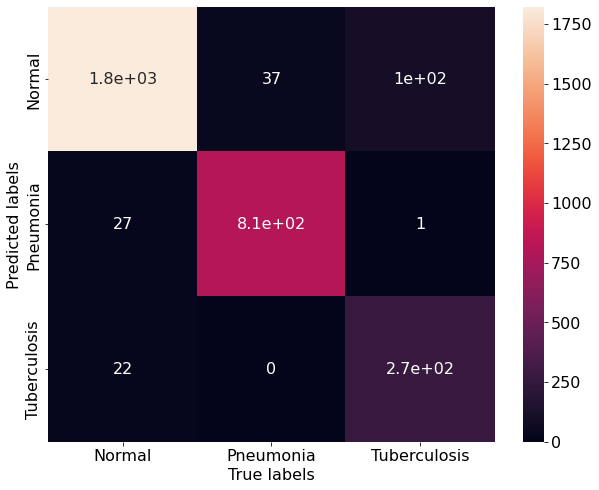

              precision    recall  f1-score   support

      Normal       0.93      0.97      0.95      1870
   Pneumonia       0.97      0.96      0.96       850
Tuberculosis       0.93      0.73      0.82       373

    accuracy                           0.94      3093
   macro avg       0.94      0.89      0.91      3093
weighted avg       0.94      0.94      0.94      3093



In [ ]:
### PREDICTION on validation set - just to check the correct upload
labels = ['Normal','Pneumonia','Tuberculosis']
evaluate(tl_model, validation_dataset)

25/25 [==============================] - 316s 13s/step
Accuracy: 0.9388
Precision: 0.9364
Recall: 0.8833
F1: 0.9368


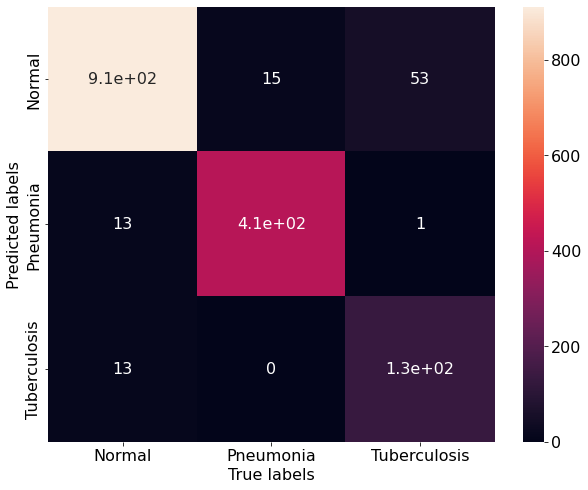

              precision    recall  f1-score   support

      Normal       0.93      0.97      0.95       937
   Pneumonia       0.97      0.96      0.97       427
Tuberculosis       0.91      0.71      0.80       188

    accuracy                           0.94      1552
   macro avg       0.94      0.88      0.91      1552
weighted avg       0.94      0.94      0.94      1552



In [ ]:
### PREDICTION on test set
labels = ['Normal','Pneumonia','Tuberculosis']
evaluate(tl_model, test_dataset)

#### 4 - Fine Tuning

In [ ]:
ft_model = tl_model 

ft_model.get_layer('efficientnetb3').trainable = True
for i, layer in enumerate(ft_model.get_layer('efficientnetb3').layers):
   print(i, layer.name, layer.trainable)

In [ ]:
# Freeze the first N layers of the network
for i, layer in enumerate(ft_model.get_layer('efficientnetb3').layers[:118]):
   layer.trainable=False
for i, layer in enumerate(ft_model.get_layer('efficientnetb3').layers):
   print(i, layer.name, layer.trainable)

In [ ]:
initial_learning_rate = 1e-5
model_compile(ft_model,initial_learning_rate)

In [ ]:
### Defining callbacks to be used in the Fine Tuning part
callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/ft_models_opt1/weights_improvement_{epoch:02d}_{val_accuracy:.2f}', 
        monitor='val_accuracy', save_best_only=True, save_weights_only=False, 
        mode='max'),
    tfk.callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min', patience=5, factor=0.5, min_lr=1e-9)
]

### Fitting the model on the training dataset
history = ft_model.fit(
    x = train_dataset,
    epochs = 200, 
    initial_epoch = 0,
    validation_data = validation_dataset,
    callbacks = callbacks_ft, 
).history

In [ ]:
### Loading the best model from the Fine Tuning part
best_model = tf.keras.models.load_model('/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/ft_models_opt1/weights_improvement_09_0.95')

49/49 [==============================] - 29s 547ms/step
Accuracy: 0.946
Precision: 0.9439
Recall: 0.9028
F1: 0.9449


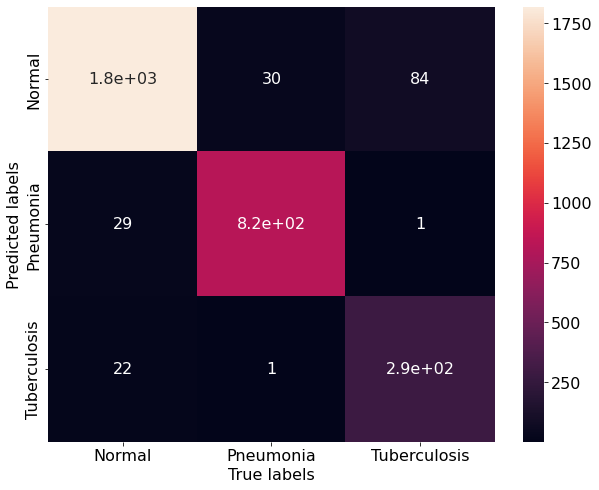

              precision    recall  f1-score   support

      Normal       0.94      0.97      0.96      1870
   Pneumonia       0.96      0.96      0.96       850
Tuberculosis       0.93      0.77      0.84       373

    accuracy                           0.95      3093
   macro avg       0.94      0.90      0.92      3093
weighted avg       0.95      0.95      0.94      3093



In [ ]:
### PREDICTION on validation set - just to check the correct upload
labels = ['Normal','Pneumonia','Tuberculosis']
evaluate(best_model, validation_dataset)

25/25 [==============================] - 661s 28s/step
Accuracy: 0.9452
Precision: 0.9401
Recall: 0.9013
F1: 0.9439


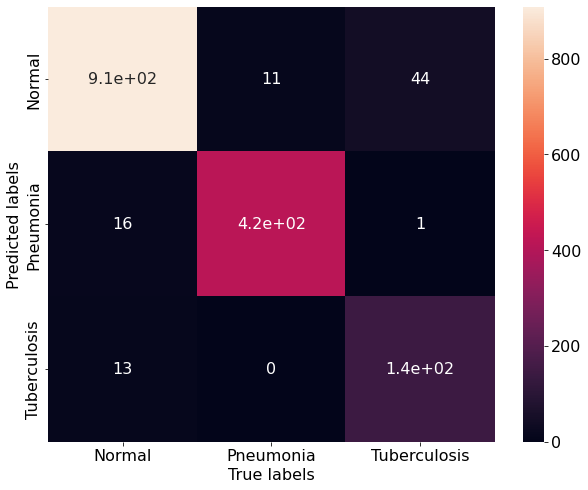

              precision    recall  f1-score   support

      Normal       0.94      0.97      0.96       937
   Pneumonia       0.96      0.97      0.97       427
Tuberculosis       0.92      0.76      0.83       188

    accuracy                           0.95      1552
   macro avg       0.94      0.90      0.92      1552
weighted avg       0.94      0.95      0.94      1552



In [ ]:
### PREDICTION on test set
labels = ['Normal','Pneumonia','Tuberculosis']
evaluate(best_model, test_dataset)

### Training 2
EfficientNetB3 (feature extractor) + Machine Learning model (classifier)

#### 1 - Data generators

In [ ]:
train_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Dataset_Option1/Train'
val_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Dataset_Option1/Validation'
test_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Dataset_Option1/Test'

In [ ]:
### Defining ROIs coordinates
img_size = 256 # image height = image width
roi_size = 10 # ROI height = ROI width

# roi 1 (top-left)
w1_start = 4
h1_start = 32
# roi 2 (top-right)
w2_start = img_size - 4 - roi_size
h2_start = 4
# roi 3 (center-right)
w3_start = img_size - 4 - roi_size
h3_start = 120
# roi 4 (bottom-right)
w4_start = img_size - 4 - roi_size
h4_start = img_size - 32 - roi_size
# roi 5 (bottom-left)
w5_start = 4
h5_start = img_size - 4 - roi_size
# roi 6 (center-left)
w6_start = 4
h6_start = 120

In [ ]:
### Preprocessing function

def check_noise(img):
  
  noisy = False
  
  roi1 = img[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
  std1 = roi1.std()
  
  roi2 = img[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
  std2 = roi2.std()
 
  roi3 = img[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size]
  std3 = roi3.std()
  
  roi4 = img[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
  std4 = roi4.std()

  roi5 = img[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size]
  std5 = roi5.std()

  roi6 = img[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size]
  std6 = roi6.std()

  if (std1>20 and std2>20 and std3>20 and std4>20 and std5>20 and std6>20):
    noisy = True
    
  return noisy


def filter_function(img):
  noisy = check_noise(img)
  if noisy :
    img = cv2.medianBlur(img, 5)
    return img/255.0
  else: 
    return img/255.0

In [ ]:
img_height = 256
img_width = 256
batch_size = 64

train_datagen = ImageDataGenerator(preprocessing_function = filter_function)
test_datagen = ImageDataGenerator(preprocessing_function = filter_function)

### Online importing
train_dataset = train_datagen.flow_from_directory(
    directory = train_dir,
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = False) 

test_dataset = test_datagen.flow_from_directory(
    directory = test_dir, 
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = False) 

Found 10825 images belonging to 3 classes.
Found 1552 images belonging to 3 classes.


NB: *In order to derive the features from the CNN, it has not to be trained so validation set is not actually needed!*




#### 2 - Feature extraction

In [ ]:
def build_feat_extractor (img_height: int, img_width: int) -> tf.keras.Model:
    net = tfk.applications.EfficientNetB3(
          include_top = False,
          weights = "imagenet", 
          input_shape = (img_height, img_width, 3)
          ) 
    net.trainable = False 
    return net 

feat_extractor = build_feat_extractor(img_height, img_width)

In [ ]:
### Extracting features from the training set
features = feat_extractor.predict(train_dataset)
print(features.shape) 
features_for_classifier = features.reshape(features.shape[0], -1)
print(features_for_classifier.shape) # features vector length = 98304

170/170 [==============================] - 82s 387ms/step
(10825, 8, 8, 1536)
(10825, 98304)


In [ ]:
### Training set labels
y_train = train_dataset.labels
print(y_train.shape) 
print(y_train) # 3 classes: 0,1,2

(10825,)
[0 0 0 ... 2 2 2]


In [ ]:
### Extracting features from the test set
features_test = feat_extractor.predict(test_dataset)
print(features_test.shape) 
features_test_for_classifier = features_test.reshape(features_test.shape[0], -1)
print(features_test_for_classifier.shape) # features vector length = 98304

25/25 [==============================] - 10s 376ms/step
(1552, 8, 8, 1536)
(1552, 98304)


In [ ]:
### Test set labels
y_test = test_dataset.labels
print(y_test.shape) 
print(y_test) # 3 classes: 0,1,2

(1552,)
[0 0 0 ... 2 2 2]


#### 3 - ML classifier fitting and evaluation

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 50, random_state = seed)

In [ ]:
# SVM (it is not supported due to the limited RAM)
'''from sklearn import svm
classifier = svm.SVC(kernel='linear') # Linear Kernel'''

In [ ]:
# AdaBoost
'''from sklearn.ensemble import AdaBoostClassifier
classifier = AdaBoostClassifier(n_estimators = 50, random_state = seed)'''

In [ ]:
### Fitting the classifier on the training features 
classifier.fit(features_for_classifier, y_train)

RandomForestClassifier(n_estimators=50, random_state=42)

In [ ]:
### Making predictions using test features 
pred = classifier.predict(features_test_for_classifier)
print(pred.shape)
print(pred)

(1552,)
[0 0 0 ... 2 0 0]


In [ ]:
### Functions used in the evaluation part

def compute_metrics(y_test, pred_number):
  
    # Computing confusion matrix
    cm = confusion_matrix(y_test, pred_number)

    # Computing classification metrics
    accuracy = accuracy_score(y_test, pred_number)
    precision = precision_score(y_test, pred_number, average='macro')
    recall = recall_score(y_test, pred_number, average='macro')
    f1 = f1_score(y_test, pred_number, average='weighted')

    # Printing classification metrics
    print('Accuracy:',accuracy.round(4))
    print('Precision:',precision.round(4))
    print('Recall:',recall.round(4))
    print('F1:',f1.round(4))

    # Plotting confusion matrix
    plt.figure(figsize=(10,8))
    sns.heatmap(cm.T, xticklabels=list(train_dataset.class_indices), yticklabels=list(train_dataset.class_indices), annot=True)
    plt.xlabel('True labels')
    plt.ylabel('Predicted labels')
    plt.show()

    print(classification_report(y_test, pred_number, target_names=labels))

Accuracy: 0.8918
Precision: 0.8854
Recall: 0.7894
F1: 0.8838


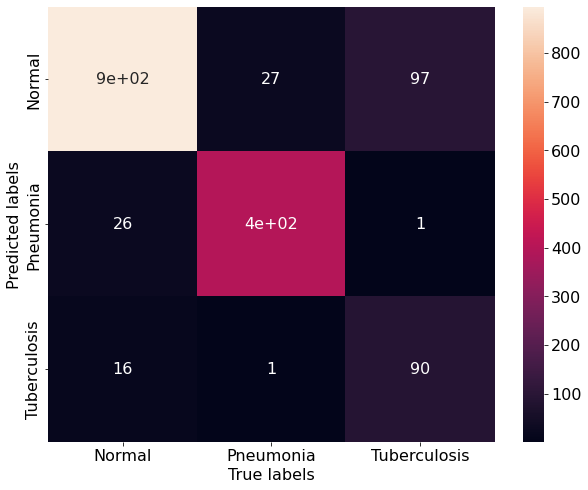

              precision    recall  f1-score   support

      Normal       0.88      0.96      0.92       937
   Pneumonia       0.94      0.93      0.94       427
Tuberculosis       0.84      0.48      0.61       188

    accuracy                           0.89      1552
   macro avg       0.89      0.79      0.82      1552
weighted avg       0.89      0.89      0.88      1552



In [ ]:
labels = ['Normal','Pneumonia','Tuberculosis']
compute_metrics(y_test, pred)